<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-2-Diabetes-Prediction-Processing/notebooks/Diabetes_Prediction_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Part 1: Exploratory Data Analysis (EDA)**
---


### **1.1: Environment Setup and Initial Ingestion**
In this stage, we initialize the analytical environment by importing essential libraries: **Pandas** for data manipulation, **NumPy** for numerical processing, and **Matplotlib/Seaborn** for statistical visualization. We then clone the project repository to access the raw `diabetes_prediction_dataset.csv` and load it into a DataFrame for initial inspection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
!git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git
os.chdir("Predicting-Type-2-Diabetes")

Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 756, done.
remote: Counting objects: 100% (196/196), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 756 (delta 118), reused 58 (delta 57), pack-reused 560 (from 3)
Receiving objects: 100% (756/756), 26.15 MiB | 14.39 MiB/s, done.
Resolving deltas: 100% (374/374), done.


In [3]:
path = "data/raw/diabetes_prediction_dataset.csv"
try:
    df = pd.read_csv(path)
    print(" Diabetes Prediction Dataset loaded successfully")
except Exception as e:
    print(f"Failed to load dataset: {e}")
df.head(10)

 Diabetes Prediction Dataset loaded successfully


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


> **Observation:** The dataset was successfully loaded from the repository. A preliminary inspection reveals a mix of demographic data, medical history, and clinical biomarkers (BMI, HbA1c, and blood glucose), providing a comprehensive feature set for diabetes prediction.



---
#
### **1.2: Structural Assessment**
Before performing analysis, we must understand the "geometry" of the data. This cell audits the total volume of records and ensures that each column is assigned the correct data type (e.g, ensuring numeric values aren't stored as strings).


In [4]:
print("-" * 30)
print(" Shape & Data Types")
print("-" * 30)
print(f"\n  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)

------------------------------
 Shape & Data Types
------------------------------

  Rows    : 100,000
  Columns : 9

Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


> **Observation:** The dataset contains **100,000 rows** across **9 features**. The features consist of a mix of `float64` (Age, BMI), `int64` (Medical flags), and `object` (Categorical strings), requiring specific preprocessing steps for the categorical variables later in the pipeline.



---

#
### **1.3: Data Integrity and Statistical Profiling**
Quality control is performed here to identify invalid medical readings. We also generate a statistical summary to understand the mean, standard deviation, and distribution ranges of our numerical features.

In [18]:
print("-" * 50)
print(" Data Quality Check & Column Summary")
print("-" * 50)

#handle invalid medical zeros (bmi, HbA1c, gluecose)
invalid_zero_cols = ['bmi', 'HbA1c_level', 'blood_glucose_level']
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

#identify column types
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# print categorical summary
print("\nCategorical Columns")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique()}")

#print numerical summary
print(f"\nNumerical Column Statistics")
print(df[numerical_cols].describe().round(2))

#print final null counts
print(f"\nNull Values after processing zeros")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No nulls found.")
print(f"Total nulls in dataset: {df.isnull().sum().sum()}")

--------------------------------------------------
 Data Quality Check & Column Summary
--------------------------------------------------

Categorical Columns

Numerical Column Statistics
            age  hypertension  heart_disease       bmi  HbA1c_level  \
count  96146.00      96146.00       96146.00  96146.00     96146.00   
mean      41.79          0.08           0.04     27.32         5.53   
std       22.46          0.27           0.20      6.77         1.07   
min        0.08          0.00           0.00     10.01         3.50   
25%       24.00          0.00           0.00     23.40         4.80   
50%       43.00          0.00           0.00     27.32         5.80   
75%       59.00          0.00           0.00     29.86         6.20   
max       80.00          1.00           1.00     95.69         9.00   

       blood_glucose_level  diabetes  
count             96146.00  96146.00  
mean                138.22      0.09  
std                  40.91      0.28  
min            

> **Observation:** The clinical markers (`bmi` and `blood_glucose_level`) show biologically consistent ranges with no missing "zero" values. The average age is approximately **41.9 years**, and the `smoking_history` feature indicates a diverse categorical spread that will require encoding.



---
#

### **1.4: Redundancy Detection (Duplicate Audit)**
High-volume datasets often contain duplicate entries which can bias machine learning models by over-representing specific patient profiles. This cell identifies the exact count and percentage of redundant records.

In [6]:
print("-" * 50)
print("Duplicate Detection")
print("-" * 50)
print(f"Number of duplicate rows found: {df.duplicated().sum()}")
print(f"Percentage of dataset that is redundant: {(df.duplicated().sum() / len(df)) * 100:.2f}%")

--------------------------------------------------
Duplicate Detection
--------------------------------------------------
Number of duplicate rows found: 3854
Percentage of dataset that is redundant: 3.85%


> **Observation:** We identified **3,854 duplicate rows** (approximately **3.85%** of the dataset). To ensure the model generalizes well and doesn't "over-learn" specific repeated profiles, these duplicates will be removed during the preprocessing stage.



---

#
### **1.5: Target Label Distribution (Class Imbalance Check)**
This is a critical check for Class Imbalance. We examine the distribution of the `diabetes` label to determine the ratio of positive cases to negative cases, which will dictate our resampling strategy and choice of evaluation metrics.

In [7]:
print("-" * 31)
print(" Class Distribution")
print("-" * 31)

class_counts = df["diabetes"].value_counts()
class_pct = df["diabetes"].value_counts(normalize=True) * 100

print(pd.DataFrame({"Count": class_counts, "Percentage (%)": class_pct.round(2)}))

-------------------------------
 Class Distribution
-------------------------------
          Count  Percentage (%)
diabetes                       
0         91500            91.5
1          8500             8.5


> **Observation:** There is a significant class imbalance: **91.5%** non-diabetic vs. **8.5%** diabetic. This confirms that standard "Accuracy" will be a misleading metric. Our modeling phase must focus on **Recall** and **F1-Score** to ensure we don't ignore the minority (diabetic) class.

---
#
### **1.6: Visualizing Feature Distributions**
To understand the underlying patterns of the data, we visualize the distributions of age, BMI, and clinical markers. This helps identify outliers and the skewness of the medical data.

#### **1.6.1: Visualizing Class Imbalance**
To visualize the disparity between the majority and minority classes, we generate a frequency bar graph of the `diabetes` target variable. This visualization provides a clear perspective on the scale of the imbalance, which is a critical factor in determining the appropriate loss functions and sampling techniques for our predictive models.

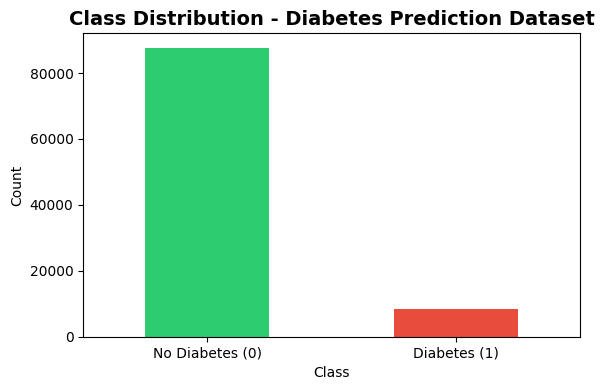

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
df["diabetes"].value_counts().plot(kind="bar", color=["#2ECC71", "#E74C3C"], ax=ax)

ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_title("Class Distribution - Diabetes Prediction Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("class_distribution_diabetes_prediction.png", dpi=150)
plt.show()

> **Observation:** The bar graph confirms a severe class imbalance. With over **91,000** instances of the negative class (No Diabetes) and fewer than **9,000** instances of the positive class (Diabetes), the "imbalance ratio" is approximately **11:1**.
>
> This visualization underscores why we cannot rely on accuracy alone; a "dummy" model that predicts 0 for every patient would still appear 91% accurate while failing to save a single life. This motivates our shift toward **Recall** and **weighted algorithms** in the later experiments.

#### **1.6.2: Multicollinearity and Relationship Mapping**
Now, we generate a Correlation Heatmap. This statistical tool allows us to identify linear relationships between features and our target variable. More importantly, it helps us detect **Multicollinearity**, a situation where two features are so highly correlated that they provide redundant information. Understanding these relationships ensures that our models, particularly Logistic Regression, are built on stable, independent predictors.

In [9]:
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

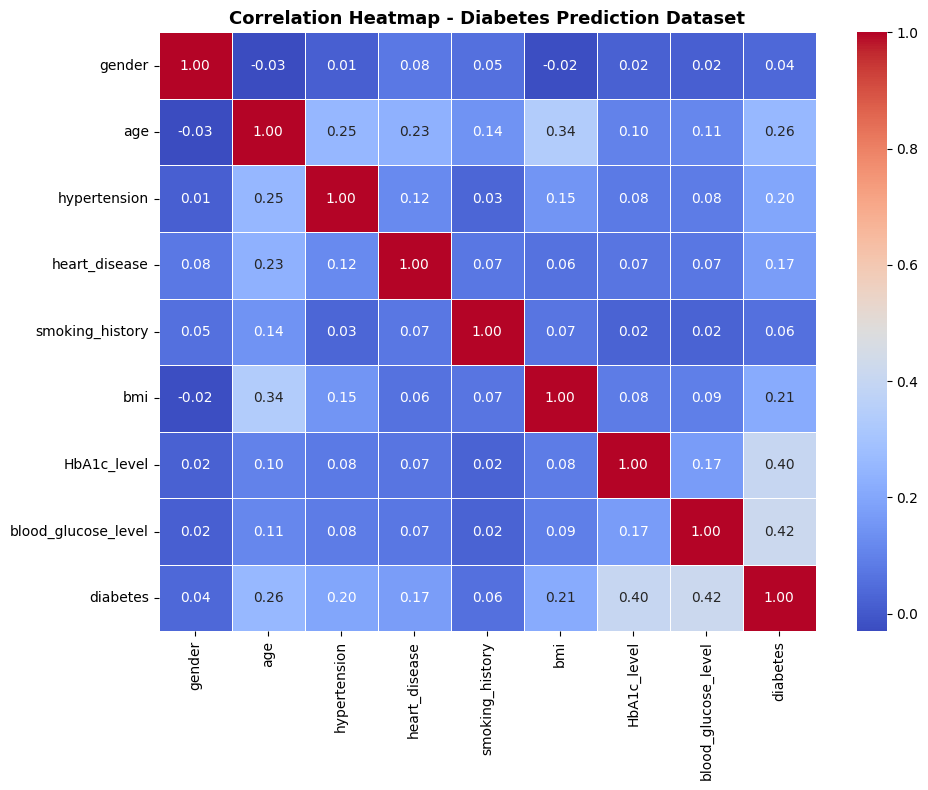

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap - Diabetes Prediction Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_diabetes_prediction.png', dpi=150)
plt.show()

> **Observation:** The heatmap provides several key insights into the dataset's internal structure:
> * **Clinical Signal:** Both **HbA1c_level** and **blood_glucose_level** show the strongest positive correlation with the diabetes target, reinforcing their importance as diagnostic markers.
> * **Demographic Links:** There is a moderate correlation between **Age** and **BMI**, which is expected as metabolic profiles often change with age.
> * **Independence:** No two features exhibit an extremely high correlation (e.g. > 0.90). This indicates that the dataset is free from severe redundancy, allowing us to utilize the full feature set in the preprocessing and modeling stages without losing statistical stability.

#### **1.6.3: Comparative Distribution Analysis**
In this step, we iterate through all predictive features to visualize their distributions relative to the `diabetes` outcome. By using a "dodge" approach for categorical variables and a "density" approach for continuous clinical markers, we can identify which features show the clearest separation between healthy and diabetic populations. This visual screening is essential for verifying that our features contain meaningful discriminatory signals.

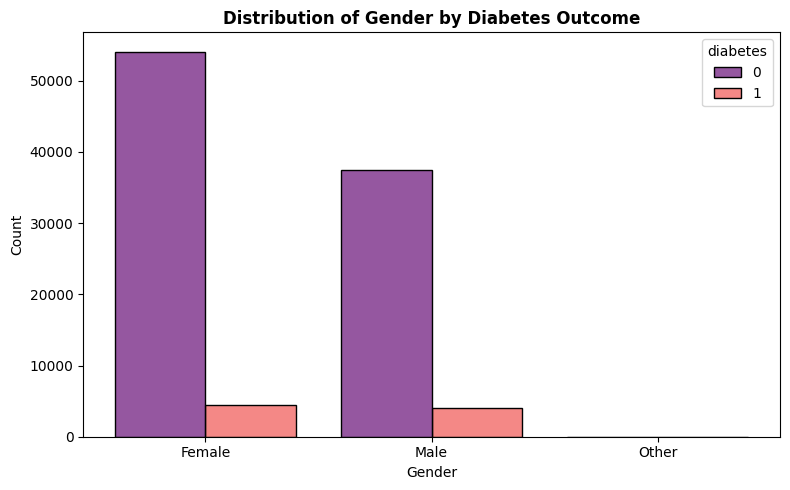

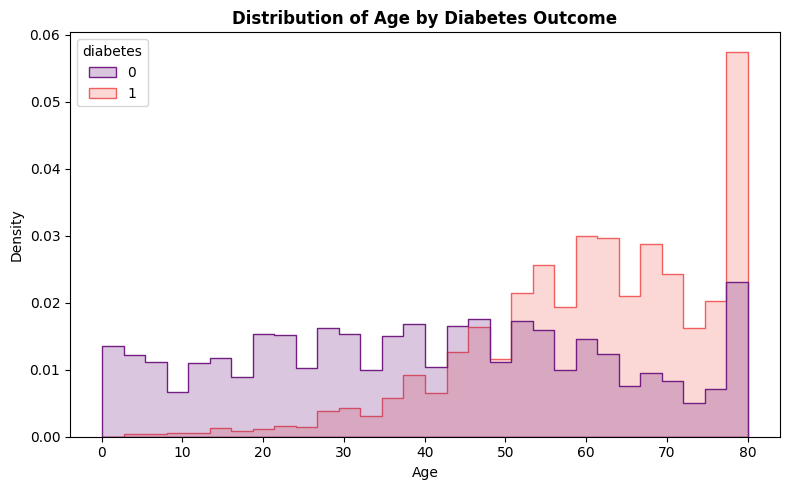

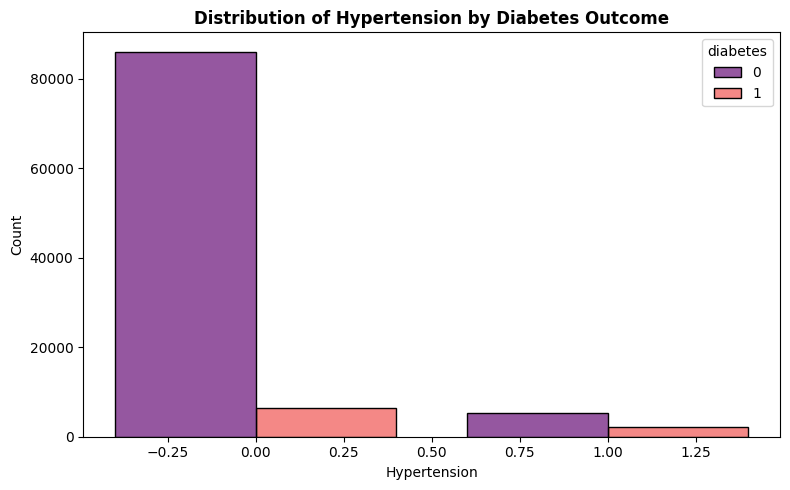

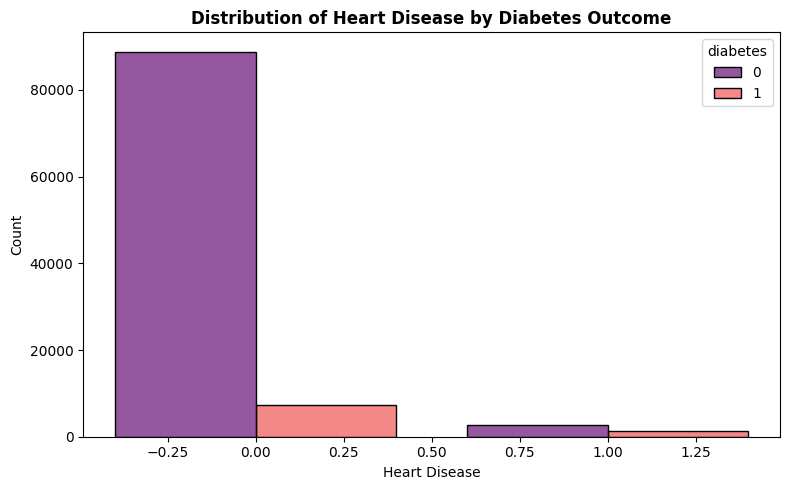

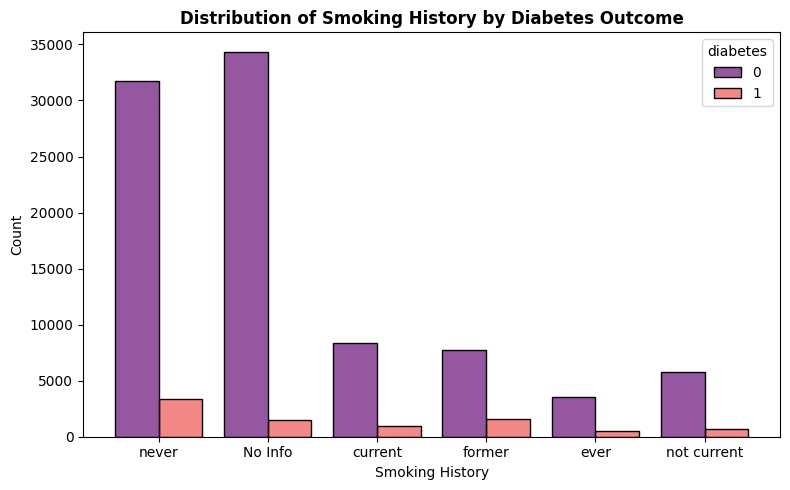

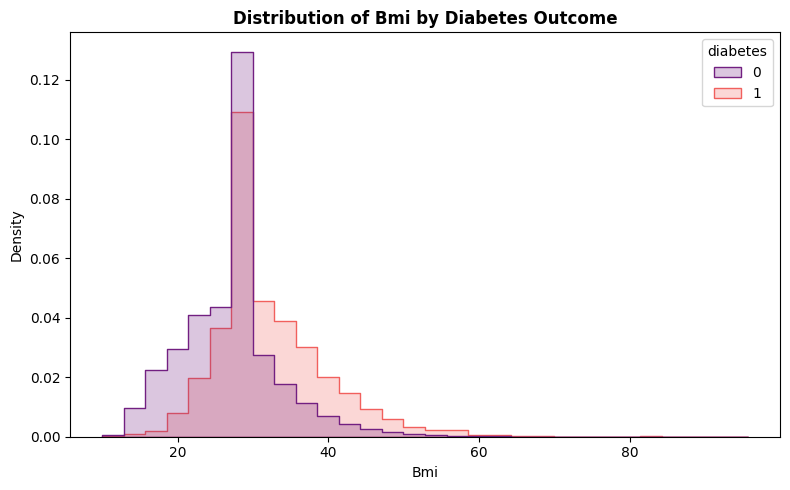

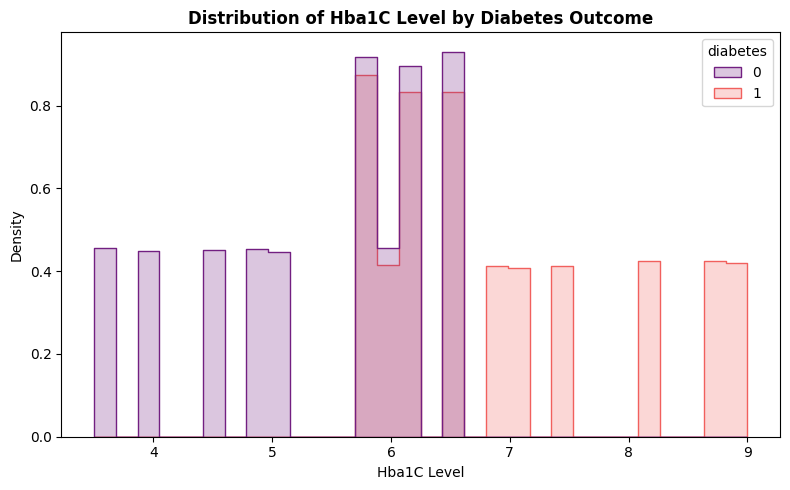

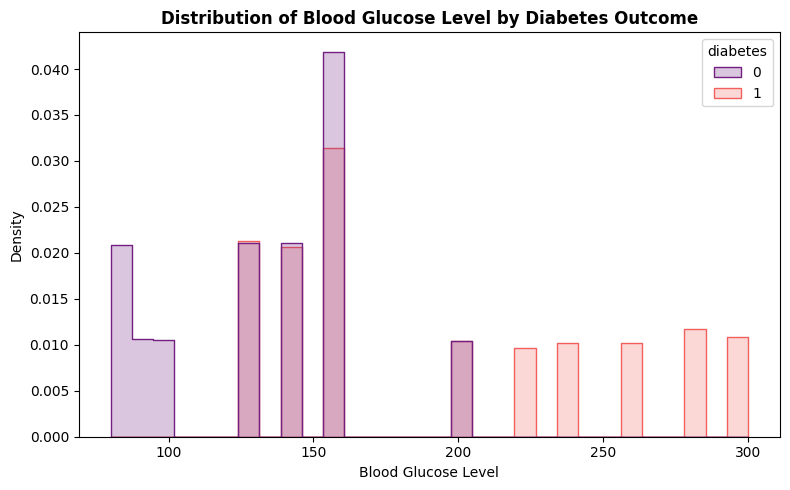

In [11]:
feature_columns = [col for col in df.columns if col != "diabetes"]

for col in feature_columns:
    plt.figure(figsize=(8, 5))

    if df[col].nunique() <= 10:
        sns.histplot(
            data=df,
            x=col,
            hue="diabetes",
            multiple="dodge",
            discrete=True,
            shrink=0.8,
            palette="magma"
        )
        plt.ylabel("Count")

    else:
        sns.histplot(
            data=df,
            x=col,
            hue="diabetes",
            bins=30,
            stat="density",
            common_norm=False,
            element="step",
            palette="magma"
        )
        plt.ylabel("Density")

    plt.title(f"Distribution of {col.replace('_', ' ').title()} by Diabetes Outcome", fontweight="bold")
    plt.xlabel(col.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()

> **Observation:** The automated distribution analysis reveals several critical patterns across the feature set:
> * **Clinical Thresholds:** Features like **HbA1c_level** and **blood_glucose_level** show distinct "spikes" in the diabetic population (purple) compared to the healthy population (orange), suggesting clear diagnostic thresholds.
> * **Demographic Risk:** The density plot for **Age** confirms that the concentration of diabetes cases increases significantly in older cohorts, whereas younger populations show a much lower density of positive outcomes.
> * **Categorical Flags:** Features with low cardinality, such as **hypertension** and **heart_disease**, show a disproportionately high count of diabetes cases when the "flag" is present, despite these conditions being less frequent in the overall dataset.
> * **BMI Overlap:** While higher **BMI** correlates with diabetes density, there is significant overlap between the two classes, suggesting that while BMI is a risk factor, it is less "definitive" on its own than the biochemical markers.



---


# **Part 2: Preprocessing Pipeline**
---



#### **2.1: Removing Redundant Observations**
During the EDA, we identified over 3,800 duplicate records. While duplicates can sometimes be valid in medical data, in a dataset of this scale, they often represent redundant entries that can lead to overfitting or biased evaluation metrics. We remove these duplicates to ensure that our model learns from unique patient profiles.

In [12]:
df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicates removed. New dataset shape: {df.shape}")

Duplicates removed. New dataset shape: (96146, 9)


> **Observation:** The removal of duplicates reduced our dataset from **100,000** to approximately **96,146** records. This creates a cleaner "ground truth" for our models and ensures that our cross-validation scores in Experiment 1 are not artificially inflated by repeated data points.

#### **2.2: Transforming Categorical Features (Encoding)**
Machine Learning models require numerical input. We transform our categorical variables (**Gender** and **Smoking History**) into a machine-readable format. For Gender, we use One-Hot Encoding to avoid implying an order, and for Smoking History, we map categories to ensure the model can distinguish between current, former, and non-smokers.

In [13]:
print("-" * 50)
print(" One-Hot Encoding - Gender & Smoking History")
print("-" * 50)

cols_to_encode = ["gender", "smoking_history"]

existing_cols = [col for col in cols_to_encode if col in df.columns]

if not existing_cols:
    print("Original columns not found. They might already be encoded!")
else:
    for col in existing_cols:
        print(f"Processing: {col}")
        print(f"  Unique values: {df[col].unique()}")
        print(f"  Value counts:\n{df[col].value_counts()}\n")

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

new_cols = [c for c in df.columns if any(sub in c for sub in cols_to_encode)]
print("-" * 50)
print(f"New columns created: {new_cols}")
print(f"Shape after encoding: {df.shape}")
print("-" * 50)

--------------------------------------------------
 One-Hot Encoding - Gender & Smoking History
--------------------------------------------------
Processing: gender
  Unique values: ['Female' 'Male' 'Other']
  Value counts:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Processing: smoking_history
  Unique values: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
  Value counts:
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

--------------------------------------------------
New columns created: ['gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
Shape after encoding: (96146, 16)
--------------------------------------------------


> **Observation:** The feature space has expanded slightly due to One-Hot Encoding. We now have distinct columns for each gender and smoking status. This allows the models (especially the tree-based ones in Experiment 2) to create specific decision branches based on lifestyle indicators without assuming a linear relationship between them.

#### **2.3: Feature Scaling and Train-Test Stratification**
Clinical features like **Age** and **Blood Glucose** have vastly different ranges (0–80 vs. 80–300). We apply **Standard Scaling** to normalize these ranges, which is essential for the convergence of Logistic Regression. Additionally, we perform a **Stratified Split** (80/20) to ensure that the 8.5% diabetes prevalence is maintained in both the training and testing sets.

In [14]:
from sklearn.model_selection import train_test_split

#features (X) and target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

#test_size=0.2 saves 20% of data for the final evaluation
#stratify=y is used because only ~9% of data is diabetic
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total rows in dataset:   {len(df)}")
print(f"Training set size:       {X_train.shape[0]} samples (80%)")
print(f"Test set size:           {X_test.shape[0]} samples (20%)")

print("\nClass Distribution - Training Set")
print(y_train.value_counts())

print("\nClass Distribution - Test Set")
print(y_test.value_counts())

Total rows in dataset:   96146
Training set size:       76916 samples (80%)
Test set size:           19230 samples (20%)

Class Distribution - Training Set
diabetes
0    70130
1     6786
Name: count, dtype: int64

Class Distribution - Test Set
diabetes
0    17534
1     1696
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler

#initialize
scaler = StandardScaler()

#fit on the training data then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#convert back to df
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("-" * 50)
print(" X_train statistics after scaling:")
print("-" * 50)
stats_summary = X_train_final.describe().T[['mean', 'std', 'min', 'max']]
print(stats_summary.round(2))

--------------------------------------------------
 X_train statistics after scaling:
--------------------------------------------------
                             mean  std   min    max
age                           0.0  1.0 -1.86   1.70
hypertension                  0.0  1.0 -0.29   3.44
heart_disease                 0.0  1.0 -0.21   4.84
bmi                          -0.0  1.0 -2.56  10.05
HbA1c_level                   0.0  1.0 -1.89   3.24
blood_glucose_level          -0.0  1.0 -1.42   3.96
gender_Female                -0.0  1.0 -1.18   0.85
gender_Male                  -0.0  1.0 -0.85   1.18
gender_Other                 -0.0  1.0 -0.01  74.11
smoking_history_No Info       0.0  1.0 -0.72   1.39
smoking_history_current      -0.0  1.0 -0.33   3.08
smoking_history_ever          0.0  1.0 -0.21   4.83
smoking_history_former       -0.0  1.0 -0.33   3.05
smoking_history_never        -0.0  1.0 -0.75   1.34
smoking_history_not current  -0.0  1.0 -0.27   3.75


> **Observation:** Post-scaling, all numerical features now have a mean of 0 and a standard deviation of 1. By using `stratify=y`, we have guaranteed that our test set is a perfect statistical representation of the original population, preventing a scenario where the test set accidentally contains too few diabetic cases for a fair evaluation.

#### **2.4: Synthetic Minority Over-sampling Technique (SMOTE)**
To combat the severe class imbalance identified in EDA, we implement **SMOTE**. This algorithm creates synthetic examples of the minority class (diabetic patients) rather than simply duplicating them. This will be the primary data-level intervention tested against the algorithmic-level intervention (Class Weighting) in Experiment 2.

In [16]:
from imblearn.over_sampling import SMOTE

#initialize
sm = SMOTE(random_state=42)

#apply to training data
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_final, y_train)

print("-" * 50)
print(" CLASS BALANCE AFTER SMOTE")
print("-" * 50)
print(f"Original distribution:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"\nResampled distribution:\n{y_train_resampled.value_counts(normalize=True)}")
print(f"\nNew Training Set Size: {X_train_resampled.shape[0]} samples")

--------------------------------------------------
 CLASS BALANCE AFTER SMOTE
--------------------------------------------------
Original distribution:
diabetes
0    0.9118
1    0.0882
Name: proportion, dtype: float64

Resampled distribution:
diabetes
0    0.5
1    0.5
Name: proportion, dtype: float64

New Training Set Size: 140260 samples


> **Observation:** The training set is now perfectly balanced (50/50 ratio). This "balanced" version of the data will allow models to learn the specific characteristics of diabetic patients without being overwhelmed by the sheer volume of healthy records.
>
> *Note: We only apply SMOTE to the training data; the test set remains imbalanced to reflect real-world clinical conditions.*

#### **2.5: Finalizing the Analytical Pipeline**
With the data cleaned, encoded, scaled, and resampled, we save the resulting datasets as optimized Parquet/CSV files. This modular approach allows us to jump straight into the experiments (Baseline, Balancing, and Generalization) without re-running the heavy preprocessing logic.

In [17]:
path = "data/preprocessed/diabetes_prediction_dataset_preprocessed"

try:
    # save Features (X) as Parquet (too big for github needed to shrink)
    X_train_resampled.to_parquet(f"{path}/X_train_scaled_smote.parquet", index=False)
    X_test_final.to_parquet(f"{path}/X_test_scaled.parquet", index=False)
    X_train_final.to_parquet(f"{path}/X_train_scaled.parquet", index=False)

    #save Targets (y) as Parquet
    y_train_resampled.to_frame().to_parquet(f"{path}/y_train_smote.parquet", index=False)
    y_test.to_frame().to_parquet(f"{path}/y_test.parquet", index=False)
    y_train.to_frame().to_parquet(f"{path}/y_train.parquet", index=False)

    print("-" * 50)
    print(" preprocessing complete!")
    print("-" * 50)
    print(f"Location: {path}")
    print("Files: X_train_scaled_smote.parquet, y_train_smote.parquet, etc.")

except Exception as e:
    print(f"Failed to save dataset: {e}")

--------------------------------------------------
 preprocessing complete!
--------------------------------------------------
Location: data/preprocessed/diabetes_prediction_dataset_preprocessed
Files: X_train_scaled_smote.parquet, y_train_smote.parquet, etc.


> **Observation:** Preprocessing is complete. We have successfully generated three versions of our data: **Original (Imbalanced)**, **Scaled**, and **Resampled (SMOTE)**. These will serve as the foundation for the upcoming four experiments.